# Homework 3: Bayesian Models and Monte Carlo

BEE 4850/5850, Spring 2025

**Name**: Luan Brito

**ID**: ls2236

> **Due Date**
>
> Friday, 3/14/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to quantify uncertainties for a simple model
    using Bayesian statistics and rejection sampling.
-   Problem 2 asks you to use Monte Carlo simulation to calculate annual
    expected flooding damages.
-   Problem 3 (only required for students in BEE 5850) asks you to
    conduct cost-benefit analyses of housing elevation levels under
    future flooding uncertainty using Monte Carlo simulations.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Projects/bee_5850/hw03-britols`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools

In [3]:
using Printf

In [4]:
using KernelDensity

## Problems

### Scoring

-   Problem 1 is worth 13 points.
-   Problem 2 is worth 7 points.
-   Problem 3 is worth 5 points.

### Problem 1

Consider the class-cheating testing procedure from [Homework
1](https://viveks.me/simulation-data-analysis/hw/hw01.html). As a
reminder, the procedure is as follows:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

Suppose that, after conducting the procedure on your class of 100
students, you get 40 “Yes, I cheated” responses. You are skeptical that
your class is broadly engaged in cheating and have a prior belief that
the probability of cheating $\theta$ is unlikely to be high. We’ll
express this prior using a beta distribution, \$(3, 40), which is shown
below. You would like to understand the range of cheating propensity
which is consistent with your prior beliefs and the outcomes from the
detection procedure.

**In this problem**:

-   Construct a Bayesian probability model (based on the data-generating
    process from Homework 1 and our prior on the cheating probability)
    for the “Yes, I cheated” counts. You can compute the likelihood
    based on the combination of the fair coin flip and the “true”
    cheating probability $\theta$.
-   Plot the posterior $p(\theta | y)$ using a grid approximation
    (looping over values of $\theta$).
-   Use rejection sampling to draw 1,000 samples from the posterior and
    plot the distribution of samples. How well are you capturing the
    posterior you obtained from the grid approximation? Would you prefer
    to have more samples?
-   Report the expected value of $\theta$ and its 90% credible interval.
    What conclusions can you draw about cheating probability and whether
    your belief in your class was warranted? How much uncertainty exists
    as a result of this privacy-protecting procedure?
-   Repeat the analysis with a less constrained prior of your choosing.
    How does that change your inferences and conclusions? What does this
    tell you about the effectiveness of the procedure?

In [5]:
#Credible interval? 

In [6]:
#--------------------------------
# Cheating model available in: https://viveks.me/simulation-data-analysis/solutions/hw/hw01/hw01.html
#--------------------------------
# cheating_model: function which simulates the outcome of the interview procedure described in this problem and returns the number of confessions obtained.
# inputs:
#   p: base probability of cheating under a given hypothesis
#   n: vector of bite counts for the water-drinking group
# output:
#   a simulated number of confessions for one realization of the process.
function cheating_model(p, n)
    # initialize the storage vector for whether students admit to cheating
    # we do this with a boolean vector, which is a little faster, but storing integers is basically the same thing
    cheat = zeros(Bool, n)
    # loop over every student to simulate the interview process
    for i in 1:n
        # initial coin flip
        # rand() simulates a uniform random number between 0 and 1
        if rand() >= 0.5
            # if this came up heads, simulate whether the student cheated based on the cheating probability
            if rand() < p
                cheat[i] = true
            else
                cheat[i] = false
            end
        else
            # otherwise, simulate another coin flip
            if rand() >= 0.5
                cheat[i] = true
            else
                cheat[i] = false
            end
        end
    end
    # return the total number of cheating admissions
    return sum(cheat)
end

cheating_model (generic function with 1 method)

In [7]:
Random.seed!(100);

#Likelihood
p = 0:0.01:1;
likelihoods = zeros(length(p));
for i in 1:length(p)
    s = [cheating_model(p[i], 100) for j in 1:50_000];
    s_mean = mean(s);
    s_stdev = std(s);
    #fit(Normal, x)
    d = Normal(s_mean,s_stdev);
    likelihoods[i] = pdf(d,40);
end

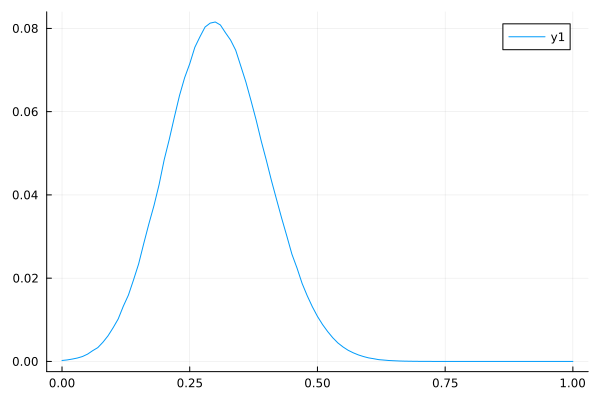

In [8]:
plot(p,likelihoods)

In [9]:
prior_dist = Beta(3,40)
prior_pdf = pdf(prior_dist,p);
posterior = prior_pdf .* likelihoods;
# Normalize to make it a proper probability distribution (sum to 1)
posterior_sum = sum(posterior);
posterior_norm = posterior ./ posterior_sum;

In [10]:
sum(p .* posterior_norm)

0.11850979464199027

In [11]:
function find_credible_interval(posterior_probs, theta_values, cred_level=0.90)
    # Ensure the arrays are ordered by theta values (if they're not already)
    # and the posterior sums to 1
    sorted_indices = sortperm(theta_values)
    sorted_thetas = theta_values[sorted_indices]
    sorted_probs = posterior_probs[sorted_indices]
    
    # Calculate cumulative probability distribution
    cum_probs = cumsum(sorted_probs)
    
    # Find the indices for the lower and upper bounds
    # This creates an equal-tailed interval with α/2 probability in each tail
    lower_idx = findfirst(p -> p >= (1 - cred_level) / 2, cum_probs)
    upper_idx = findfirst(p -> p >= 1 - (1 - cred_level) / 2, cum_probs)
    
    # Return the credible interval
    return [sorted_thetas[lower_idx], sorted_thetas[upper_idx]]
end

# Example usage:
cred_interval = find_credible_interval(posterior_norm, p, 0.90)

2-element Vector{Float64}:
 0.05
 0.2

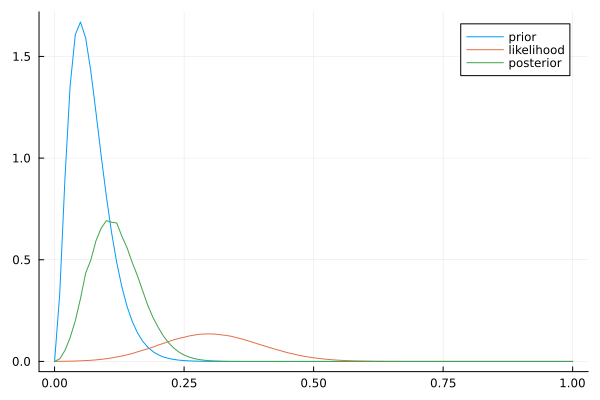

In [12]:
plot(p,prior_pdf/sum(p.*prior_pdf),label="prior")
plot!(p,likelihoods/sum(p.*likelihoods),label="likelihood")
plot!(p,posterior/sum(p.*posterior),label="posterior")

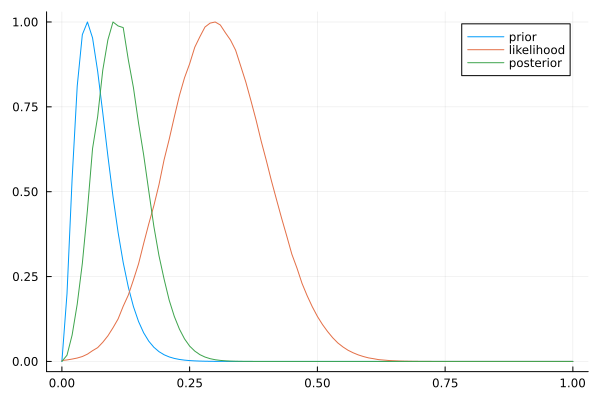

In [13]:
plot(p,prior_pdf/maximum(prior_pdf),label="prior")
plot!(p,likelihoods/maximum(likelihoods),label="likelihood")
plot!(p,posterior/maximum(posterior),label="posterior")

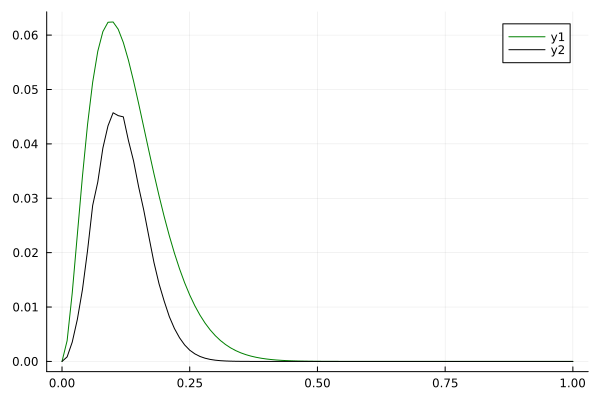

In [14]:
proposal_dist = Beta(3,20)
proposal_pdf = pdf(proposal_dist,p)/100;
plot(p,proposal_pdf,color=:green)
plot!(p,posterior,color=:black)

In [15]:
Random.seed!(100);

proposal_dist = Beta(3,20)
proposal_pdf = pdf(proposal_dist,p)/100;
p = 0:0.01:1;
samples = 1000
random_x = rand(proposal_dist,samples);
random_y = (pdf(proposal_dist,random_x)/100) .* rand(samples);

x_in = []
y_in = []
x_out = []
y_out = []
plt=plot(p,proposal_pdf)
for i in 1:length(random_x)
    #x[i] = collect(p)[argmin(abs.(collect(p) .- random_x[i]))]
    y = posterior[argmin(abs.(collect(p) .- random_x[i]))]
    if random_y[i] > y
        push!(x_out,random_x[i])
        push!(y_out,random_y[i])

    else
        push!(x_in,random_x[i])
        push!(y_in,random_y[i])
    end
end

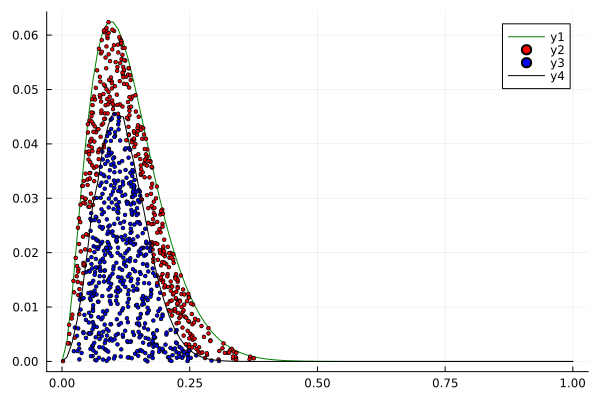

In [16]:
plot(p,proposal_pdf,color=:green)
scatter!(x_out,y_out,color=:red,markersize = 2)
scatter!(x_in,y_in,color=:blue,markersize = 2)
plot!(p,posterior,color=:black)

In [17]:
#print("Kept ",length(x_in)/length(x)*100,"%")
@printf "Kept  %.1f" 100*length(x_in)/length(random_x)
print("% of the proposals")

Kept  55.8% of the proposals

In [18]:
x_in = Float64.(x_in);
k = kde(x_in);

In [19]:
mean(x_in)

0.1201141943850079

In [20]:
mean(posterior./maximum(posterior))

0.12068241365466274

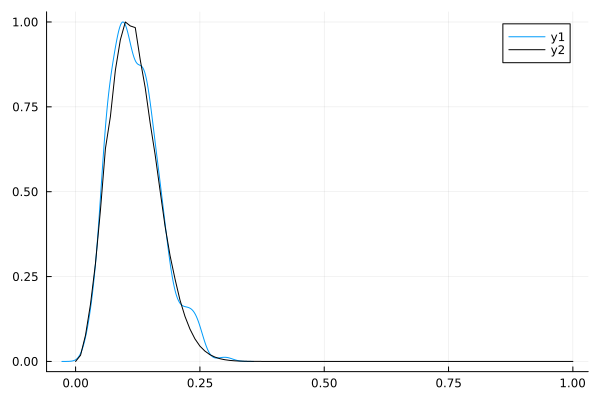

In [21]:
p1 = plot(k.x,k.density/maximum(k.density))
plot!(p1,p,posterior./maximum(posterior),color=:black)
#vline!(p1, [mode(x_in)], linestyle=:dash, color=:red, linewidth=3, minorgrid=true)
#vline!(p1, [mode(posterior/maximum(posterior))], linestyle=:dash, color=:blue, linewidth=3, minorgrid=true)


In [22]:
posterior_prev = posterior;


In [23]:
prior_dist = Beta(1,1)
prior_pdf = pdf(prior_dist,p);
posterior = prior_pdf .* likelihoods;
# Normalize to make it a proper probability distribution (sum to 1)
posterior_sum = sum(posterior);
posterior_norm = posterior ./ posterior_sum;

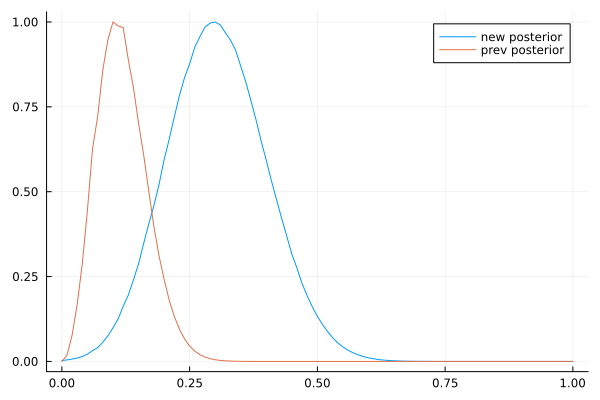

In [24]:
plot(p,posterior_norm/maximum(posterior_norm),label="new posterior")
plot!(p,posterior_prev/maximum(posterior_prev),label="prev posterior")

In [25]:
sum(p .* posterior_norm)

0.30397586369657115

In [26]:
find_credible_interval(posterior_norm, p, 0.90)

2-element Vector{Float64}:
 0.15
 0.46

### Problem 2

You have been asked by a client to assess the risks of flooding to their
home (which is valued at \$400,000 and only floods when the stream water
levels exceed 1.5m). They would like to know the probability
distribution of annual flood damages to their home if they do not take
any preventative floodproofing measures. After some hydrologic analysis,
you have developed a 40-year record of annual maximum water levels (in
m) at the nearby stream.

You also have a depth-damage function for the fraction of the home’s
value which is damaged at varying flood depths:

$$d(h) = \mathbb{I}[h > 0] \frac{1}{1+\exp(-k(x-x_0))},$$

where $k=1.25$ and $x_0=2$[1]. The graph of this function is given in
the figure below.

[1] As a reminder, the indicator function $\mathbb{I}[h > 0]$ is $0$
when the condition is not satisfied (in this case, when $h=0$) and $1$
when it is satisfied.

**In this problem**:

-   Fit a log-normal distribution to the water depth data by maximizing
    likelihood.
-   Use 10,000 samples from this distribution to estimate the expected
    damages from an annual maximum flood event using Monte Carlo
    simulation. Report your estimate as well as its standard error.
    Would you want to use more samples? Why or why not?

**Answer:** The fitted log-normal parameters, estimated by MLE, are θ_mle = [0.14058, 0.24964]. 10,000 samples from the distribution were used to estimate the expected damages from an annual maximum flood event, for each sample it was calculated the damage cost (as a fraction of the home's value) using the depth-damage function. After multiplying the fraction to the home's value, it was found Mean = $5,767 (95% C.I. = [$5,483,$6,051]) and Standard deviation: $14,479.

I believe 10,000 is enough for this problem for the following reasons:
- The mean and standard deviation of the lognormal annual maximum water level distribution are 1.1873 m and 0.3011 m, the 10,000 samples have a mean of 1.1868 m and std of 0.3008 m. 
- Looking at the plot of estimated mean damage cost by simulation size, we can see diminishing flutuations after 5000 iterations

In [27]:
#Read data
data = CSV.read("data/water_depths.csv", DataFrame); # load data into DataFrame
obs = data.depths;

In [28]:
#Fit lognormal distribution to data
function fit_lognormal(θ,depth)
    a,b = θ
    ll = sum(logpdf.(LogNormal.(a, b), depth)) # compute log-likelihood
    return ll
end
lb = [0.0, 0.0]
ub = [1, 1]
θ₀ = [0.1, 0.1]

optim_out = Optim.optimize(θ -> -fit_lognormal(θ, obs), lb, ub, θ₀)
θ_mle = round.(optim_out.minimizer; digits=5)
@show θ_mle;
sim_dist = LogNormal(θ_mle[1],θ_mle[2]);

θ_mle = [0.14058, 0.24964]


In [29]:
mean(h_sim)

UndefVarError: UndefVarError: `h_sim` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [30]:
std(h_sim)

UndefVarError: UndefVarError: `h_sim` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [31]:
#Generate 10,000 samples
Random.seed!(100);
n_samples = 10_000;
h_sim = rand(sim_dist,n_samples);

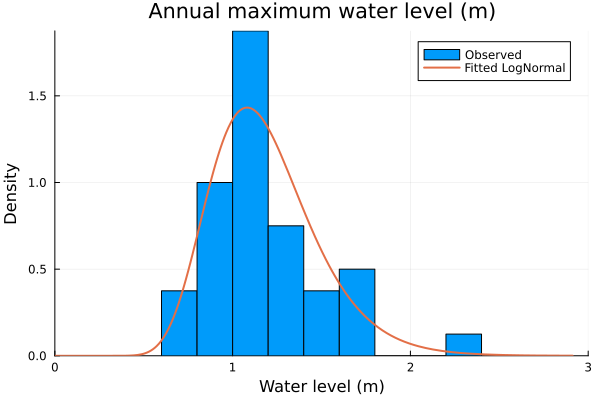

In [32]:
histogram(obs,normalize=:pdf,label="Observed")
plot!(sim_dist,xlim=[0,3],lw=2, label="Fitted LogNormal")
title!("Annual maximum water level (m)")
xlabel!("Water level (m)")
ylabel!("Density")

In [33]:
function damage_function(k ,x₀,h)
    if(h>0)
        damage = 1/(1+exp(-k.*(h.-x₀)))
    else
        damage = 0
    end
    return damage
end;

In [34]:
x₀ = 2;
k = 1.25;
house_price = 400000
h_obs = obs;
damage_obs = house_price * damage_function.(k,x₀,(h_obs .- 1.5));
damage_sim = house_price * damage_function.(k,x₀,(h_sim .- 1.5));

In [35]:
@printf "Mean:  %.4f" mean(damage_obs)
@printf "\nStandard deviation: %.4f" std(damage_obs)

Mean:  7382.4302
Standard deviation: 17452.3694

In [36]:
@printf "Mean:  %.4f" mean(damage_sim)
@printf "\nStandard deviation: %.4f" std(damage_sim)

Mean:  5766.9909
Standard deviation: 14479.0927

In [ ]:
# show Monte Carlo estimate stabilization
avg_mc_out = zeros(n_samples)
#avg_mc_out[1] = damage_sim[1]
std_mc_out = zeros(n_samples)
#std_mc_out[1] = 0
for i = 1:n_samples
    if i == 1
        avg_mc_out[i] = damage_sim[1]
        std_mc_out[i] = 0
    else
        avg_mc_out[i] = mean(damage_sim[1:i])
        std_mc_out[i] = 1/sqrt(i) * std(damage_sim[1:i])
    end
end


# show Monte Carlo estimate stabilization
#avg_mc_out = zeros(n_samples)
#avg_mc_out[1] = damage_sim[1]
#std_mc_out = zeros(n_samples)
#std_mc_out[1] = 0
#for i = 2:n_samples
#    avg_mc_out[i] = (avg_mc_out[i-1] * (i-1) + (damage_sim[i])) / i
#    std_mc_out[i] = 1/sqrt(i) * std(damage_sim[1:i])
#end

In [ ]:
avg_mc_out[end]+1.96*std_mc_out[end]  #[5483,6051]

In [ ]:
avg_mc_out[end]-1.96*std_mc_out[end]

In [ ]:
p = plot(avg_mc_out, xlabel="Iteration", ylabel="Cost (\$)",  legend=:false, ribbon=1.96*std_mc_out, fillalpha=0.3, linewidth=2, tickfontsize=16, guidefontsize=18, fillcolor=:red, minorgrid=true)
hline!(p,[avg_mc_out[end]],linestyle=:dash,color=:black)
ylims!(p, (0, 10000))

#display(p)
#xlims!(p, (0, 500))
#title!(p,"First 500 Monte Carlo iterations")
#plot!(p, size=(600, 450))
#display(p)
#xlims!(p, (9500, 10000))
#title!(p,"Last 500 Monte Carlo iterations")
#display(p)

In [ ]:
return_periods = [2, 5, 10, 25, 50, 100, 250, 500];
qs = 1 .- (1 ./ return_periods);
return_levels = quantile(damage_sim, qs);
ci_e = std(damage_sim)/sqrt(n_samples)
# function to calculate exceedance probability and plot positions based on data quantile
function exceedance_plot_pos(y)
    N = length(y)
    ys = sort(y; rev=false) # sorted values of y
    nxp = xp = [r / (N + 1) for r in 1:N] # exceedance probability
    xp = 1 .- nxp
    return xp, ys
end

xp, ys = exceedance_plot_pos(damage_obs);

In [ ]:
h_sim_og = h_sim;
damage_sim_og = damage_sim;

In [ ]:
#damage_scenarios = zeros(length(dh),length(h_sim))
damage_scenarios = zeros(n_samples,6)
h_scenarios = zeros(n_samples,6)
h_scenarios[:,1] = h_sim_og;
damage_scenarios[:,1]=damage_sim_og;
temp = []
for i in 2:size(damage_scenarios)[2]
    #Random.seed!(i)
    h_sim_temp = rand(sim_dist,n_samples)
    h_scenarios[:,i] = h_sim_temp
    damage_scenarios[:,i] = house_price * damage_function.(k,x₀,(h_sim_temp .- 1.5));

    #push!(temp,NPV(damage_sim[:,i],T,0.04))
end
#NPV_scenarios[i,:] = temp


In [ ]:
violin(["original" "1" "2" "3" "4" "5" "6"],h_scenarios,label=false)

In [ ]:
violin(["original" "1" "2" "3" "4" "5" "6"],damage_scenarios,label=false)

In [ ]:
#damage_sim = Float64.(damage_sim);
#damage_obs = Float64.(damage_obs);

#k_sim = kde(damage_sim);
#k_obs = kde(damage_obs);

#p1 = plot(k_sim.x,k_sim.density,label="Sim")
#plot!(p1,k_obs.x,k_obs.density,label="Obs")
#vline!(p1, [mean(damage_sim)], linestyle=:dash, color=:blue, linewidth=1, minorgrid=true,label="mean Sim")
#vline!(p1, [mean(damage_obs)], linestyle=:dash, color=:red, linewidth=1, minorgrid=true,label="mean Obs")


#p1 = histogram(damage_obs,bins=5,label=false,title="Damage distribution using observations",xlabel="Damage",ylabel="Density")
#vline!(p1, [mean(damage_obs)], linestyle=:dash, color=:blue, linewidth=2, minorgrid=true,label="Mean obs")
#vline!(p1, [mean(damage_sim)], linestyle=:dash, color=:red, linewidth=2, minorgrid=true,label="Mean sim")
#xlims!(p1, (0, 0.3))
#p2 = histogram(damage_sim,bins=10,label=false,title="Damage distribution using simulations",xlabel="Damage",ylabel="Density",color=:orange)
#vline!(p2, [mean(damage_obs)], linestyle=:dash, color=:blue, linewidth=2, minorgrid=true,label="Mean obs")
#vline!(p2, [mean(damage_sim)], linestyle=:dash, color=:red, linewidth=2, minorgrid=true,label="Mean sim")
#xlims!(p2, (0, 0.3))
#plot(p1,p2,size=(900, 500))


#damage_sim = Float64.(damage_sim);
#k = kde(damage_sim);#[damage_sim .> 0]);
#p1 = plot(k.x,k.density/maximum(k.density))
#vline!(p1, [mean(damage_sim)], linestyle=:dash, color=:red, linewidth=1, minorgrid=true,label="mean")

### Problem 3

<span style="color:red;">GRADED FOR 5850 STUDENTS ONLY</span>

Next, your client would like advice on whether it would be
cost-effective to elevate their home to reduce flood risks. To address
this question, you will need to calculate the **net present value
(NPV)** of flooding damages, which converts damages over time to a
present value using a discount rate[1] For example, if your discount
rate is 4%, a dollar next year is worth the equivalent of about 96 cents
today. More generally, with a discount rate of $\gamma$ (as a decimal),
a dollar of benefits in $t$ years is worth $\$(1-\gamma)^t$ today.

The NPV of a sequence of money $x_t$ with discount rate $\gamma$ is the
sum of all of the discounted values, that is,

$$NPV = \sum_{t=0}^T x_t (1-\gamma)^t,$$

where $T$ is the time horizon. We’ll use a discount rate of 4% in this
problem, which is typical for this type of problem, and a design horizon
of 30 years.

For this problem, we will assume that the cost of elevating the house
$\Delta h$ m is
$C(\Delta h) = \mathbb{I}[h > 0](100,000 + 2,000\Delta h)$.

[1] Discount rates reduce future monetary values to reflect the
time-value of money; that is, you would rather have a bit less money
today than none today and more next year, as you could save or invest
that money. The actual choice of discount rates is the subject of much
economic theory and plays an important role in environmental
decision-making, particularly for multi-generational investments such as
climate mitigation. For example, with a relatively large discount rate
(such as 7%), all costs and benefits after a decade are effectively
zero, which means it never appears cost-effective to e.g. reduce fossil
fuel emissions.

> **Tip**
>
> Be careful about the quantity you’re estimating. Calculating the
> benefits of elevating by $\Delta h$ m requires calculating how the
> elevation *changes* the expected flooding damages over the design
> horizon *relative to a no-heightening baseline*.

**In this problem**:

-   Using the extreme water level distribution from Problem 2, use Monte
    Carlo simulation to estimate the NPV of the benefits of elevation
    levels between 0 and 5m (you don’t have to consider increments finer
    than 0.5m). What elevation heights pass the cost-benefit test? You
    can assume that the costs of elevation are all up front (that is, in
    year 0).
-   What height (including a possible elevation of 0m) maximizes the NPV
    of net benefits (benefits - ocsts)?[1]

[1] This is an example of **Monte Carlo optimization** as you are using
Monte Carlo simulation to estimate the optimization objective function.

In [ ]:
function NPV(x,T,γ)
    NPV_i = zeros(length(x));
    for (i,t) in pairs(0:(T-1));
        NPV_i[i] = x[i] * (1-γ)^(t);
    end
    return sum(NPV_i);
end

function elevating_cost(dh)
    C_h = 0;
    if dh > 0
        C_h = 100000+2000*dh;
    end
    return C_h;
end

In [ ]:
dh = 0:0.5:5;
dh_array = collect(dh);
C_h = elevating_cost.(dh_array);

In [ ]:
#Random.seed!(100)
n_samples=10_000
T=30
h_sim = rand(sim_dist,T,n_samples);

In [ ]:
#damage_scenarios = zeros(length(dh),length(h_sim))
NPV_scenarios = zeros(length(dh),n_samples)
House_price = 400000
for (i,h) in pairs(dh)
    #print(i,"\n")
    #damage_scenarios[i,:] = damage_function.(k,x₀,(h_sim .- (1.5+h)));
    damage_sim = damage_function.(k,x₀,(h_sim .- (1.5+h)));
    #damage_sim = Float64.(damage_sim);
    damage_sim = House_price .* damage_sim;
    temp = []
    for i in 1:size(damage_sim)[2]
        push!(temp,NPV(damage_sim[:,i],T,0.04))
    end
    NPV_scenarios[i,:] = temp
end;

In [ ]:
mean_NPV = map(mean,eachrow(NPV_scenarios));
baseline = mean_NPV[1];
std_NPV = map(std,eachrow(NPV_scenarios));
ci_NPV = 1.96*std_NPV/sqrt(n_samples);
mean_NPV_diff = baseline .- mean_NPV;
upper_NPV_diff = (baseline + ci_NPV[1]) .- (mean_NPV + ci_NPV);
lower_NPV_diff = (baseline - ci_NPV[1]) .- (mean_NPV - ci_NPV);

In [ ]:
#benefits
P90=C_h-((mean_NPV[1]+(1.96*ci_NPV[1])) .- mean_NPV +(1.96*ci_NPV))
baseline = mean_NPV[1];
benefits = baseline .- mean_NPV;
costs = C_h;
net = benefits - costs;
upper_net = upper_NPV_diff - costs;
lower_net = lower_NPV_diff - costs;
plot(net)
plot!(upper_net)
plot!(lower_net)


In [ ]:
print(collect(dh),"\n",map(mean,eachrow(NPV_scenarios)),"\n",(map(std,eachrow(NPV_scenarios))))

In [ ]:
baseline = mean(NPV_scenarios[1,:])
lt_damage = map(mean,eachrow(NPV_scenarios))
benefits = baseline .- lt_damage;
print(benefits,"\n",C_h)

In [ ]:
for i in 1:size(NPV_scenarios)[1]
    l = length(NPV_scenarios[i,:]);
    m = NPV_scenarios[i,:][NPV_scenarios[i,:] .> 0];
    print(length(m)/l,"\n")
end
#histogram(NPV_scenarios[1,:])
#histogram!(NPV_scenarios[2,:])
#maximum(NPV_scenarios[3,:])